# LANL 3SBB — Experimental Data Exploration & Synthetic Comparison

This notebook loads both the IQS experimental dataset and the reduced-order synthetic dataset
for the Los Alamos National Laboratory 3-Storey Benchmark Building (3SBB).

**Datasets**
- `experimental_frfs.h5` — 2 638 H1 FRF measurements (0–100 Hz, 1601 pts, 9 channels)  
  acquired at IQS with the original LANL benchmark under 67 experimental configurations.
- `synthetic_frfs.h5` — 17 FRFs from a **semi-rigid** reduced-order Euler–Bernoulli model  
  (JSR = 7.90, tuned to match the IQS first resonance at ~20.94 Hz).

**Sections**
1. Setup & data loading  
2. Building geometry & sensor layout  
3. Experimental dataset overview  
4. Pristine FRF gallery  
5. Damage effect on FRFs  
6. Reduced-order model vs experiment  
7. CFDAC matrices (damage indicator)  
8. Experimental variability analysis

In [1]:
import numpy as np
import h5py, json
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.gridspec import GridSpec
from collections import Counter
from pathlib import Path

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

DATA_DIR = Path('.')
EXP_H5   = DATA_DIR / 'experimental_frfs.h5'
SYN_H5   = DATA_DIR / 'synthetic_frfs.h5'

print('Experimental:', EXP_H5, '  exists:', EXP_H5.exists())
print('Synthetic:   ', SYN_H5, '  exists:', SYN_H5.exists())

Experimental: experimental_frfs.h5   exists: True
Synthetic:    synthetic_frfs.h5   exists: True


## 1. Load datasets

In [2]:
with h5py.File(EXP_H5, 'r') as f:
    exp_data   = f['data'][:]           # (2638, 1601, 9)  complex64  (m/s²)/N
    exp_freq   = f['freq'][:]           # (1601,)  Hz
    exp_labels = f['labels'][:]         # (2638,)  int32
    exp_cases  = [c.decode() for c in f['cases'][:]]
    exp_nums   = f['file_nums'][:]
    exp_lmap   = json.loads(f.attrs['label_map_json'])

exp_label2case = {v: k for k, v in exp_lmap.items()}
N_EXP = exp_data.shape[0]
print(f'Experimental : {N_EXP} measurements, {len(exp_lmap)} unique cases')
print(f'Freq axis    : {exp_freq[0]:.4f} – {exp_freq[-1]:.1f} Hz  (Δf={exp_freq[1]-exp_freq[0]:.4f} Hz)')
print(f'Shape        : {exp_data.shape}  dtype={exp_data.dtype}  units=(m/s²)/N')

Experimental : 2638 measurements, 67 unique cases
Freq axis    : 0.0000 – 100.0 Hz  (Δf=0.0625 Hz)
Shape        : (2638, 1601, 9)  dtype=complex64  units=(m/s²)/N


In [3]:
with h5py.File(SYN_H5, 'r') as f:
    _syn_raw   = f['frfs'][:]           # (17, 1601, 9)  complex64  mm/s²/N
    syn_freqs  = f['freqs'][:]          # (1601,)  float32  Hz
    syn_cnames = [f['case_names'][i].decode() if isinstance(f['case_names'][i], bytes)
                  else str(f['case_names'][i]) for i in range(len(f['case_names']))]
    syn_model  = f.attrs.get('model', 'N/A')
    syn_units  = f.attrs.get('units', 'mm/s²/N')
    syn_sens   = f.attrs.get('sensors', '')
    syn_inp    = f.attrs.get('input',   '')

# Convert to experiment units: mm/s²/N → (m/s²)/N
syn_data = _syn_raw / 1000.0
N_SYN    = len(syn_cnames)

print(f'Synthetic model  : {syn_model}')
print(f'Stored units     : {syn_units}  →  converted to (m/s²)/N')
print(f'Sensors          : {syn_sens}')
print(f'Input            : {syn_inp}')
print(f'\nCases ({N_SYN}):')
for i, nm in enumerate(syn_cnames):
    print(f'  [{i:2d}] {nm}')

Synthetic model  : N/A
Stored units     : mm/s²/N  →  converted to (m/s²)/N
Sensors          : 
Input            : 

Cases (17):
  [ 0] Pristine
  [ 1] D(11%) 1BD
  [ 2] D(11%) 2BD
  [ 3] D(11%) 3BD
  [ 4] D(20%) 1BD
  [ 5] D(20%) 2BD
  [ 6] D(20%) 3BD
  [ 7] D(50%) 1BD
  [ 8] D(50%) 2BD
  [ 9] D(85%) 1BD
  [10] D(85%) 2BD
  [11] D(85%) 3BD
  [12] D(85%) 1BD+2BD
  [13] Crack 5mm 1BD
  [14] Crack 8mm 1BD
  [15] Hole 4mm 1BD
  [16] Hole 6mm 1BD


## 2. Building geometry & sensor layout

The 3SBB has four 305 × 305 × 25.4 mm aluminium plates connected by
25.4 × 6.4 mm columns. The base plate rolls on Y-direction rails.  
Nine accelerometers (Y-direction) sit at the **column–floor attachment points**
(three per upper floor). A shaker excites the **mid-face of the base plate's
–Y side** in the Y-direction.

| Signal | Floor | Position |
|--------|-------|----------|
| 2  | 1 | low-x, –Y face |
| 5  | 1 | high-x, –Y face |
| 6  | 1 | low-x, +Y face |
| 7  | 2 | low-x, –Y face |
| 8  | 2 | high-x, –Y face |
| 11 | 2 | low-x, +Y face |
| 12 | 3 | low-x, –Y face |
| 13 | 3 | high-x, –Y face |
| 14 | 3 | low-x, +Y face |

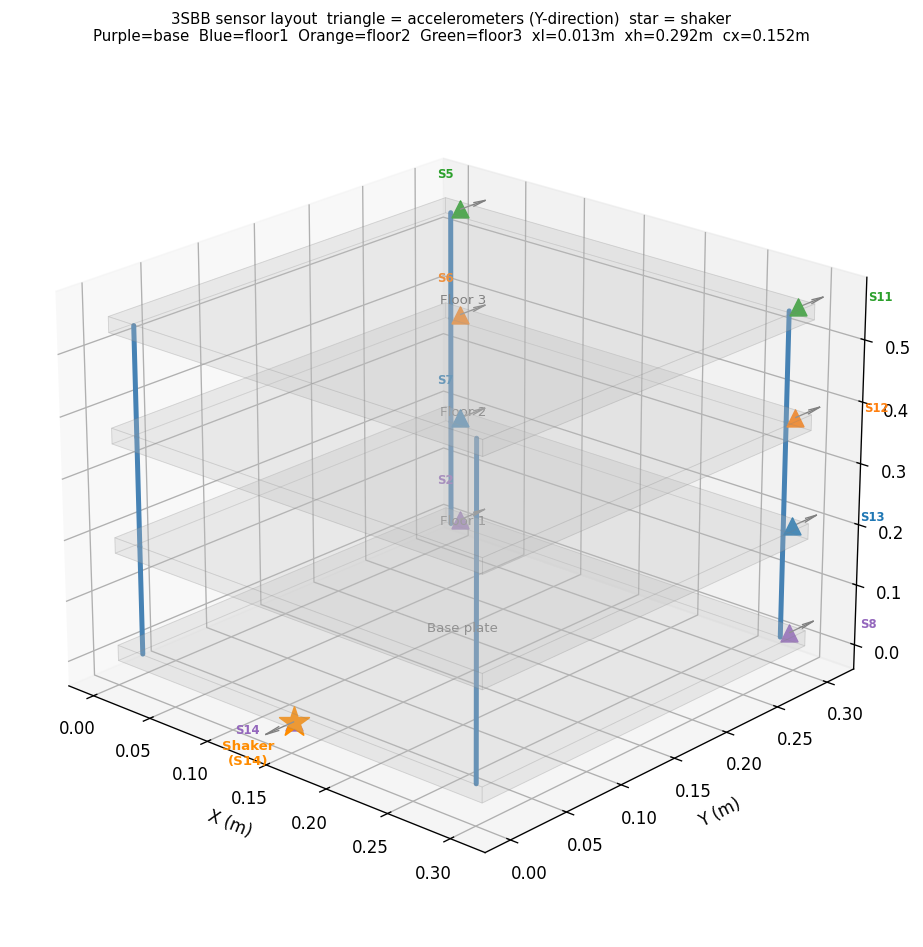

Sensor positions (model_3sbb._sensor_positions):
  ch   Sig    x(m)      y(m)      z(m)      Location
    0  S2       0.0127    0.3050    0.0127  base +Y xl
    1  S5       0.0127    0.3050    0.5461  fl3 +Y xl
    2  S6       0.0127    0.3050    0.3683  fl2 +Y xl
    3  S7       0.0127    0.3050    0.1905  fl1 +Y xl
    4  S8       0.2923    0.3050    0.0127  base +Y xh
    5  S11      0.2923    0.3050    0.5461  fl3 +Y xh
    6  S12      0.2923    0.3050    0.3683  fl2 +Y xh
    7  S13      0.2923    0.3050    0.1905  fl1 +Y xh
    8  S14      0.1525    0.0000    0.0127  base -Y cx


In [4]:
# Physical parameters (params.py)
PL   = 0.305           # plate side length  (m)
PT   = 0.0254          # plate thickness    (m)
CLX  = 0.0254          # column wide dim    (m)
CLY  = 0.0064          # column thin dim    (m)
CGAP = 0.0005          # column-plate gap   (m)
SH   = PT + 0.1524     # storey height      (m)  = 0.1778 m

# Plate z-centres  (k=0 base ... k=3 roof)
z_pl = [k * SH + PT / 2 for k in range(4)]
z0, z1, z2, z3 = z_pl

# Sensor x-coordinates (from model_3sbb._sensor_positions)
xl = CLX / 2           # 0.0127 m  low-x column centre
xh = PL - xl           # 0.2923 m  high-x column centre
cx = PL / 2            # 0.1525 m  plate centroid x

# 9 sensor positions in HDF5 channel order
# S2..S13 are on +Y face (y=PL); S14 is on -Y face (y=0) = shaker reference
SENSOR_POS = [
    (xl, PL, z0),   # ch0  S2   base plate, +Y face, xl  [inverted polarity in exp]
    (xl, PL, z3),   # ch1  S5   floor 3,    +Y face, xl
    (xl, PL, z2),   # ch2  S6   floor 2,    +Y face, xl
    (xl, PL, z1),   # ch3  S7   floor 1,    +Y face, xl
    (xh, PL, z0),   # ch4  S8   base plate, +Y face, xh
    (xh, PL, z3),   # ch5  S11  floor 3,    +Y face, xh
    (xh, PL, z2),   # ch6  S12  floor 2,    +Y face, xh
    (xh, PL, z1),   # ch7  S13  floor 1,    +Y face, xh
    (cx, 0.,  z0),  # ch8  S14  base plate, -Y face, cx  (shaker reference / input)
]
SIGNAL_NAMES = [2, 5, 6, 7, 8, 11, 12, 13, 14]
SHAKER_POS   = (cx, 0., z0)   # mid-face of base plate, -Y side

FLOOR_CLR = {z0: "tab:purple", z1: "tab:blue", z2: "tab:orange", z3: "tab:green"}

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Floor plates
floor_labels = ["Base plate", "Floor 1", "Floor 2", "Floor 3"]
for k, zc in enumerate(z_pl):
    zb, zt = zc - PT/2, zc + PT/2
    v = [[0,0,zb],[PL,0,zb],[PL,PL,zb],[0,PL,zb],
         [0,0,zt],[PL,0,zt],[PL,PL,zt],[0,PL,zt]]
    faces = [[v[i] for i in idx]
             for idx in [(0,1,2,3),(4,5,6,7),(0,1,5,4),(3,2,6,7),(0,3,7,4),(1,2,6,5)]]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.15,
                        facecolor="silver", edgecolor="gray", lw=0.5))
    ax.text(PL/2, PL/2, zt + 0.006, floor_labels[k],
            ha="center", va="bottom", fontsize=8, color="dimgray")

# Columns (4 corners x 3 stories)
col_corners = [(xl, xl - CLY/2 - CGAP), (xh, xl - CLY/2 - CGAP),
               (xl, PL - xl + CLY/2 + CGAP), (xh, PL - xl + CLY/2 + CGAP)]
for cxc, cyc in col_corners:
    for s in range(3):
        ax.plot([cxc,cxc],[cyc,cyc],[z_pl[s],z_pl[s+1]],
                color="steelblue", lw=3, solid_capstyle="round")

# Sensors
label_offsets = {
    "S2": (-0.04, 0.03), "S8": (0.04, 0.03), "S14": (0.00, -0.04),
    "S5": (-0.04, 0.03), "S11": (0.04, 0.03),
    "S6": (-0.04, 0.03), "S12": (0.04, 0.03),
    "S7": (-0.04, 0.03), "S13": (0.04, 0.03),
}
for i, (sx, sy, sz) in enumerate(SENSOR_POS):
    clr   = FLOOR_CLR.get(sz, "crimson")
    sname = f"S{SIGNAL_NAMES[i]}"
    dx, dy = label_offsets.get(sname, (0., 0.03))
    ax.scatter([sx],[sy],[sz], s=100, c=clr, marker="^", zorder=5, depthshade=False)
    ax.text(sx+dx, sy+dy, sz+0.010, sname,
            fontsize=7, color=clr, ha="center", va="bottom", fontweight="bold")

# Shaker (orange star at S14)
sx, sy, sz = SHAKER_POS
ax.scatter([sx],[sy],[sz], s=350, c="darkorange", marker="*", zorder=6, depthshade=False)
ax.text(sx, sy-0.04, sz+0.006, "Shaker\n(S14)",
        fontsize=8, color="darkorange", ha="center", va="top", fontweight="bold")

# Y-direction arrows
arr_len = 0.025
for sx, sy, sz in SENSOR_POS:
    dy_arr = -arr_len if sy < 0.01 else arr_len
    ax.quiver(sx, sy, sz, 0, dy_arr, 0, length=1.0,
              color="gray", arrow_length_ratio=0.5, lw=0.8)

ax.set_xlabel("X (m)", labelpad=6)
ax.set_ylabel("Y (m)", labelpad=6)
ax.set_zlabel("Z (m)", labelpad=6)
ax.set_title(
    "3SBB sensor layout  triangle = accelerometers (Y-direction)  star = shaker\n"
    "Purple=base  Blue=floor1  Orange=floor2  Green=floor3  "
    "xl=0.013m  xh=0.292m  cx=0.152m",
    pad=10, fontsize=9
)
ax.view_init(elev=22, azim=-48)
plt.tight_layout()
plt.show()

print("Sensor positions (model_3sbb._sensor_positions):")
print(f"  {'ch':3s}  {'Sig':5s}  {'x(m)':8s}  {'y(m)':8s}  {'z(m)':8s}  Location")
locs = ["base +Y xl","fl3 +Y xl","fl2 +Y xl","fl1 +Y xl",
        "base +Y xh","fl3 +Y xh","fl2 +Y xh","fl1 +Y xh","base -Y cx"]
for i, ((sx,sy,sz), nm) in enumerate(zip(SENSOR_POS, SIGNAL_NAMES)):
    print(f"  {i:3d}  S{nm:<4d}  {sx:8.4f}  {sy:8.4f}  {sz:8.4f}  {locs[i]}")


## 3. Experimental dataset overview

Total measurements : 2638
Unique cases       : 61

Top 15 cases by count:
   382  Pristine
    97  Mass Base
    80  Hole 4mm 1BD
    61  Mass First Floor
    40  Damage (85%) 1BD
    40  Damage (85%) 1BD + Mass Base
    40  Damage (85%) 1BD + Mass 1F
    40  D(85%) 1AD + D(85%) 1BD
    40  D(85%) 1AD + D(85%) 1BD + Mass Base
    40  D(85%) 1AD + D(85%) 1BD + Mass First Floor
    40  D(85%) 2BD
    40  D(85%) 2BD + Mass Base
    40  D(85%) 2BD + Mass First Floor
    40  D(85%) 2BD + D(85%) 2AD
    40  D(85%) 2BD + D(85%) 2AD + Mass Base


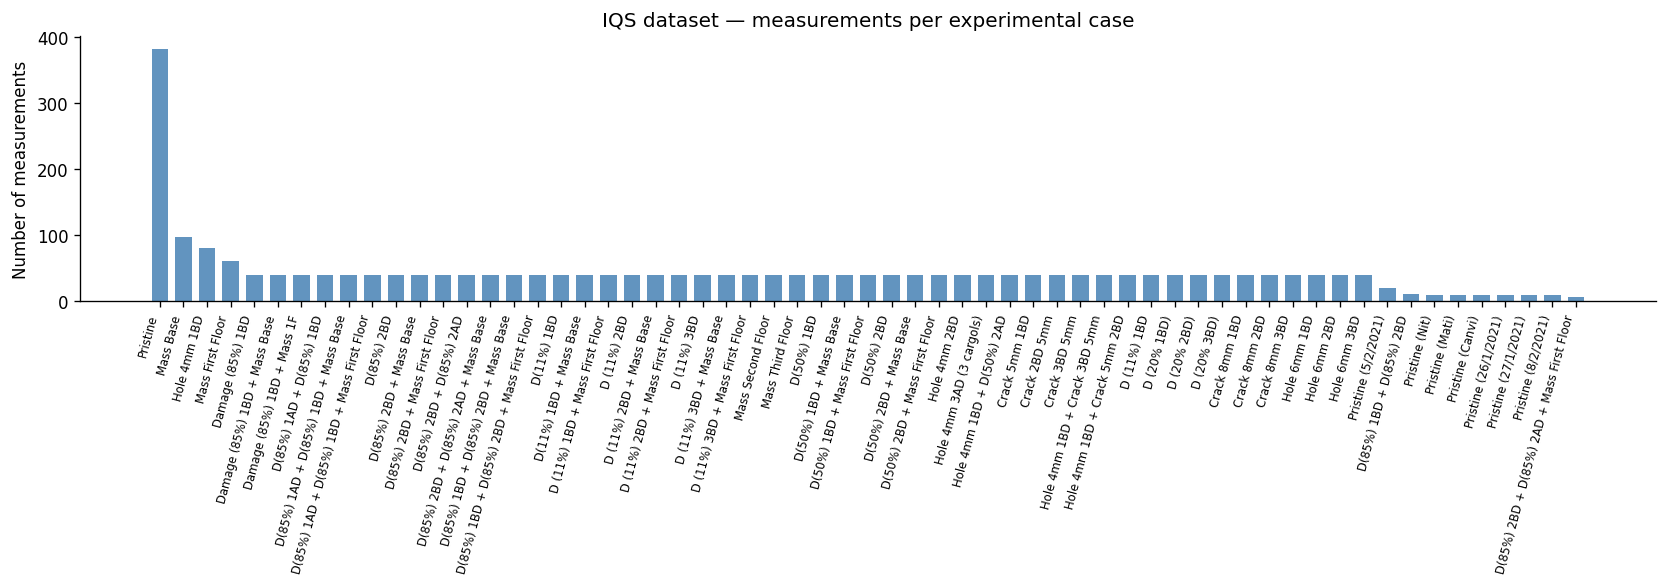

In [5]:
case_counts  = Counter(exp_cases)
sorted_cases = sorted(case_counts.items(), key=lambda x: -x[1])

print(f'Total measurements : {N_EXP}')
print(f'Unique cases       : {len(case_counts)}')
print('\nTop 15 cases by count:')
for nm, cnt in sorted_cases[:15]:
    print(f'  {cnt:4d}  {nm}')

fig, ax = plt.subplots(figsize=(14, 5))
names  = [n for n, _ in sorted_cases]
counts = [c for _, c in sorted_cases]
ax.bar(range(len(names)), counts, color='steelblue', width=0.7, alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=75, ha='right', fontsize=7)
ax.set_ylabel('Number of measurements')
ax.set_title('IQS dataset — measurements per experimental case')
plt.tight_layout()
plt.show()

## 4. Pristine FRF gallery

Pristine measurements : 382


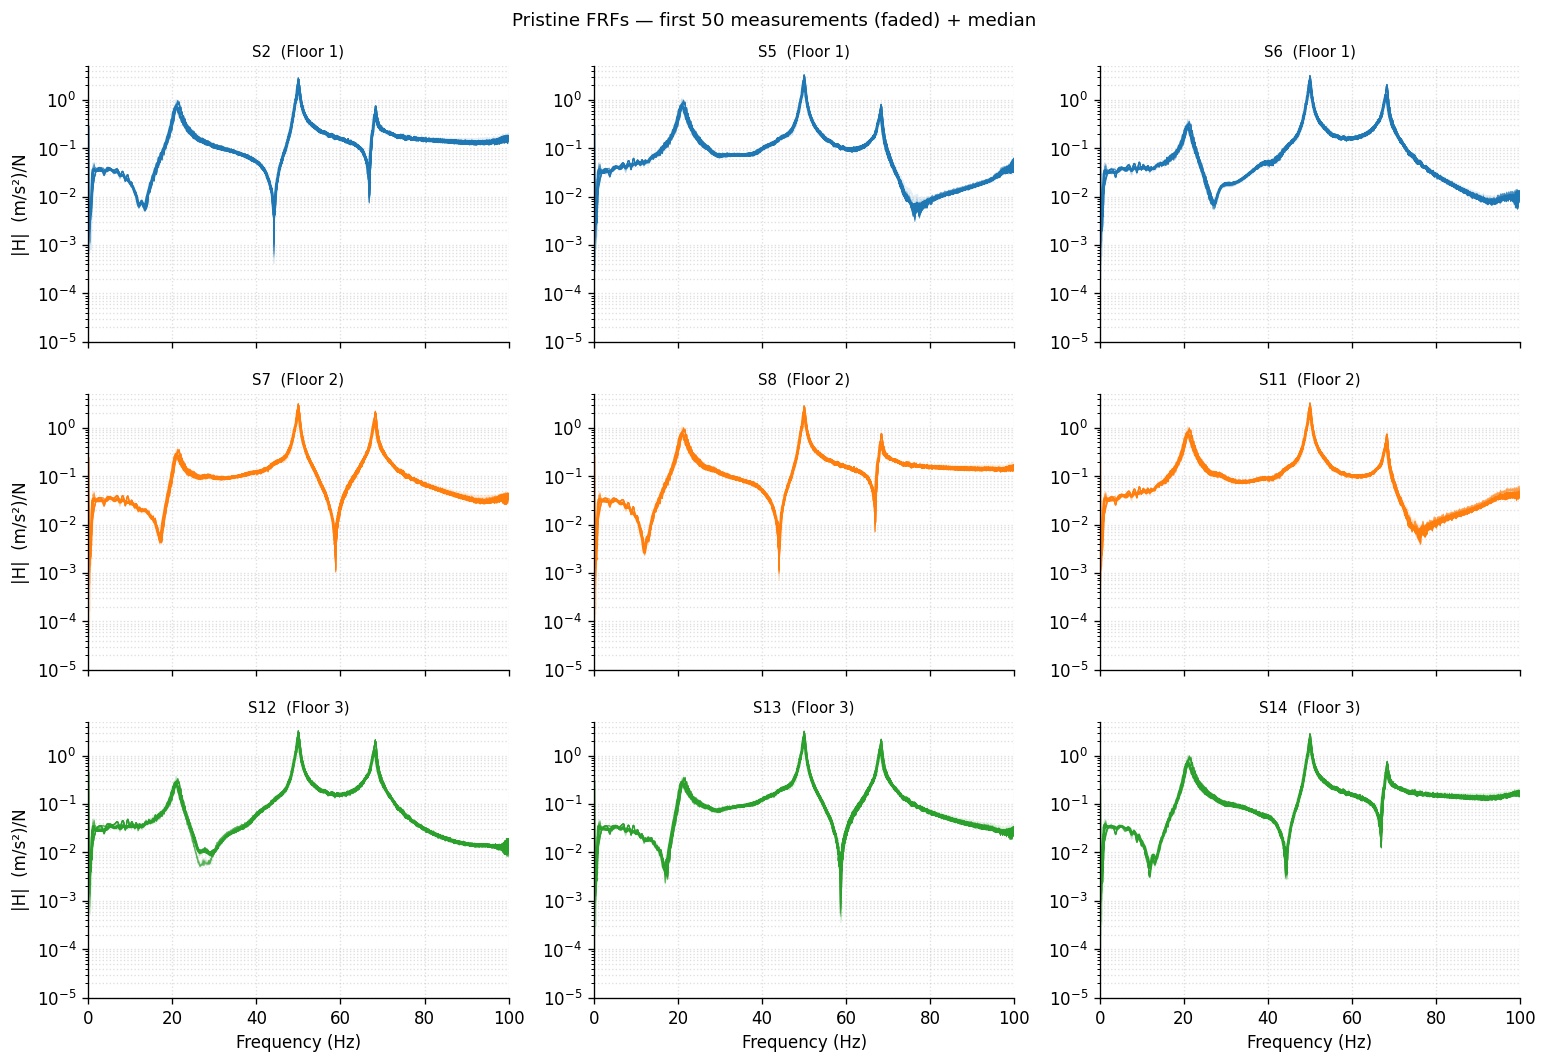

In [6]:
SIG_LABELS = [f'S{n}' for n in [2, 5, 6, 7, 8, 11, 12, 13, 14]]
FLOOR_COLS = ['tab:blue', 'tab:orange', 'tab:green']
FLOOR_SIG  = [[0,1,2], [3,4,5], [6,7,8]]

def get_exp_case(case_name):
    idx = exp_lmap.get(case_name)
    if idx is None:
        return None
    return exp_data[exp_labels == idx]

pristine_H = get_exp_case('Pristine')
print(f'Pristine measurements : {len(pristine_H)}')

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
for fi, chans in enumerate(FLOOR_SIG):
    for ci, ch in enumerate(chans):
        ax  = axes[fi][ci]
        col = FLOOR_COLS[fi]
        for m in range(min(len(pristine_H), 50)):
            ax.semilogy(exp_freq, np.abs(pristine_H[m, :, ch]),
                        alpha=0.12, color=col, lw=0.6)
        med = np.median(np.abs(pristine_H[:, :, ch]), axis=0)
        ax.semilogy(exp_freq, med, color=col, lw=1.8, label='Median')
        ax.set_title(f'{SIG_LABELS[ch]}  (Floor {fi+1})', fontsize=9)
        ax.set_ylim(1e-5, 5); ax.set_xlim(0, 100)
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if fi == 2: ax.set_xlabel('Frequency (Hz)')
        if ci == 0: ax.set_ylabel('|H|  (m/s²)/N')

fig.suptitle('Pristine FRFs — first 50 measurements (faded) + median', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Damage effect on FRFs

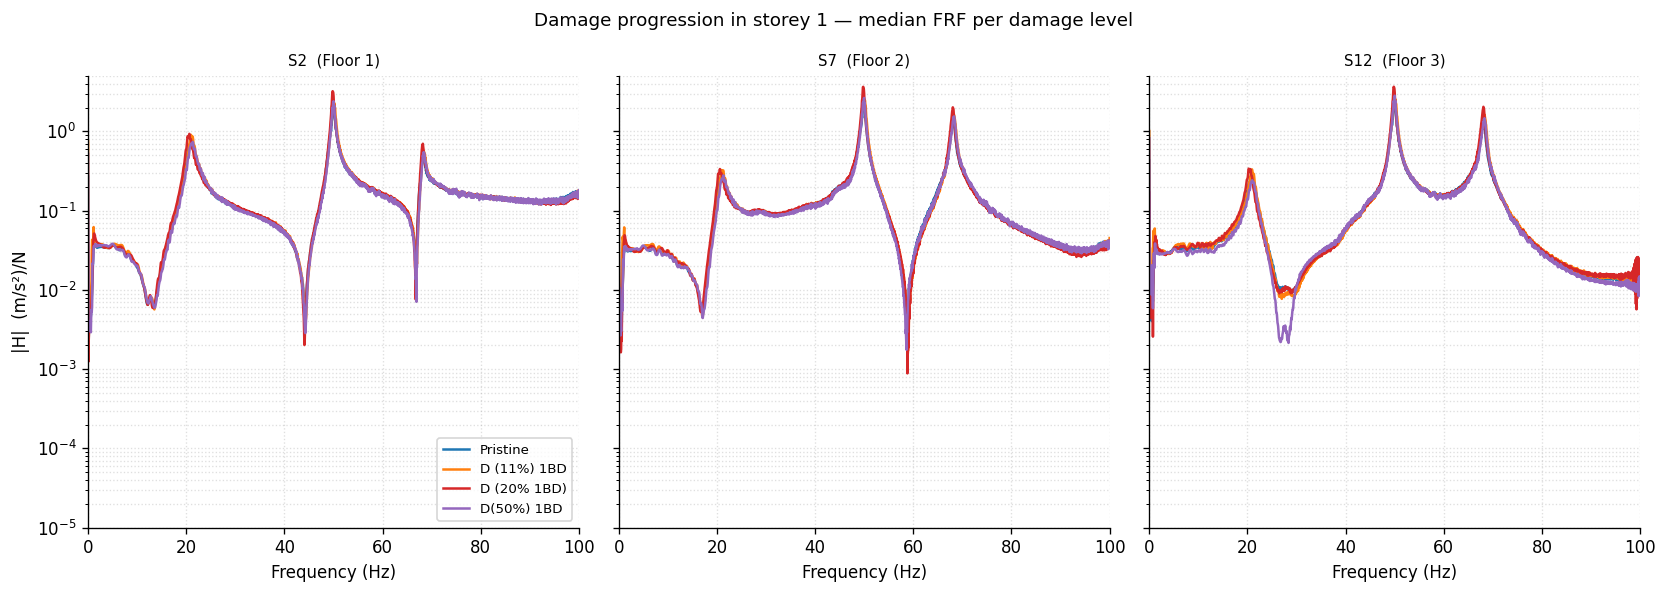

In [7]:
damage_cases = [
    ('Pristine',       'Pristine'),
    ('D (11%) 1BD',    'D (11%) 1BD'),
    ('D (20% 1BD)',    'D (20% 1BD)'),
    ('D(50%) 1BD',     'D(50%) 1BD'),
]
DCOLS = ['tab:blue', 'tab:orange', 'tab:red', 'tab:purple']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)
for fi, chans in enumerate(FLOOR_SIG):
    ax = axes[fi]
    ch = chans[0]   # low-x, –Y channel per floor
    for (lbl, case_name), col in zip(damage_cases, DCOLS):
        H = get_exp_case(case_name)
        if H is None or len(H) == 0:
            print(f'  [WARNING] no data for "{case_name}"')
            continue
        med = np.median(np.abs(H[:, :, ch]), axis=0)
        ax.semilogy(exp_freq, med, color=col, lw=1.5, label=lbl)
    ax.set_title(f'{SIG_LABELS[chans[0]]}  (Floor {fi+1})', fontsize=9)
    ax.set_ylim(1e-5, 5); ax.set_xlim(0, 100)
    ax.set_xlabel('Frequency (Hz)')
    ax.grid(True, which='both', ls=':', alpha=0.4)
    if fi == 0:
        ax.set_ylabel('|H|  (m/s²)/N')
        ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Damage progression in storey 1 — median FRF per damage level', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Reduced-order model vs experiment

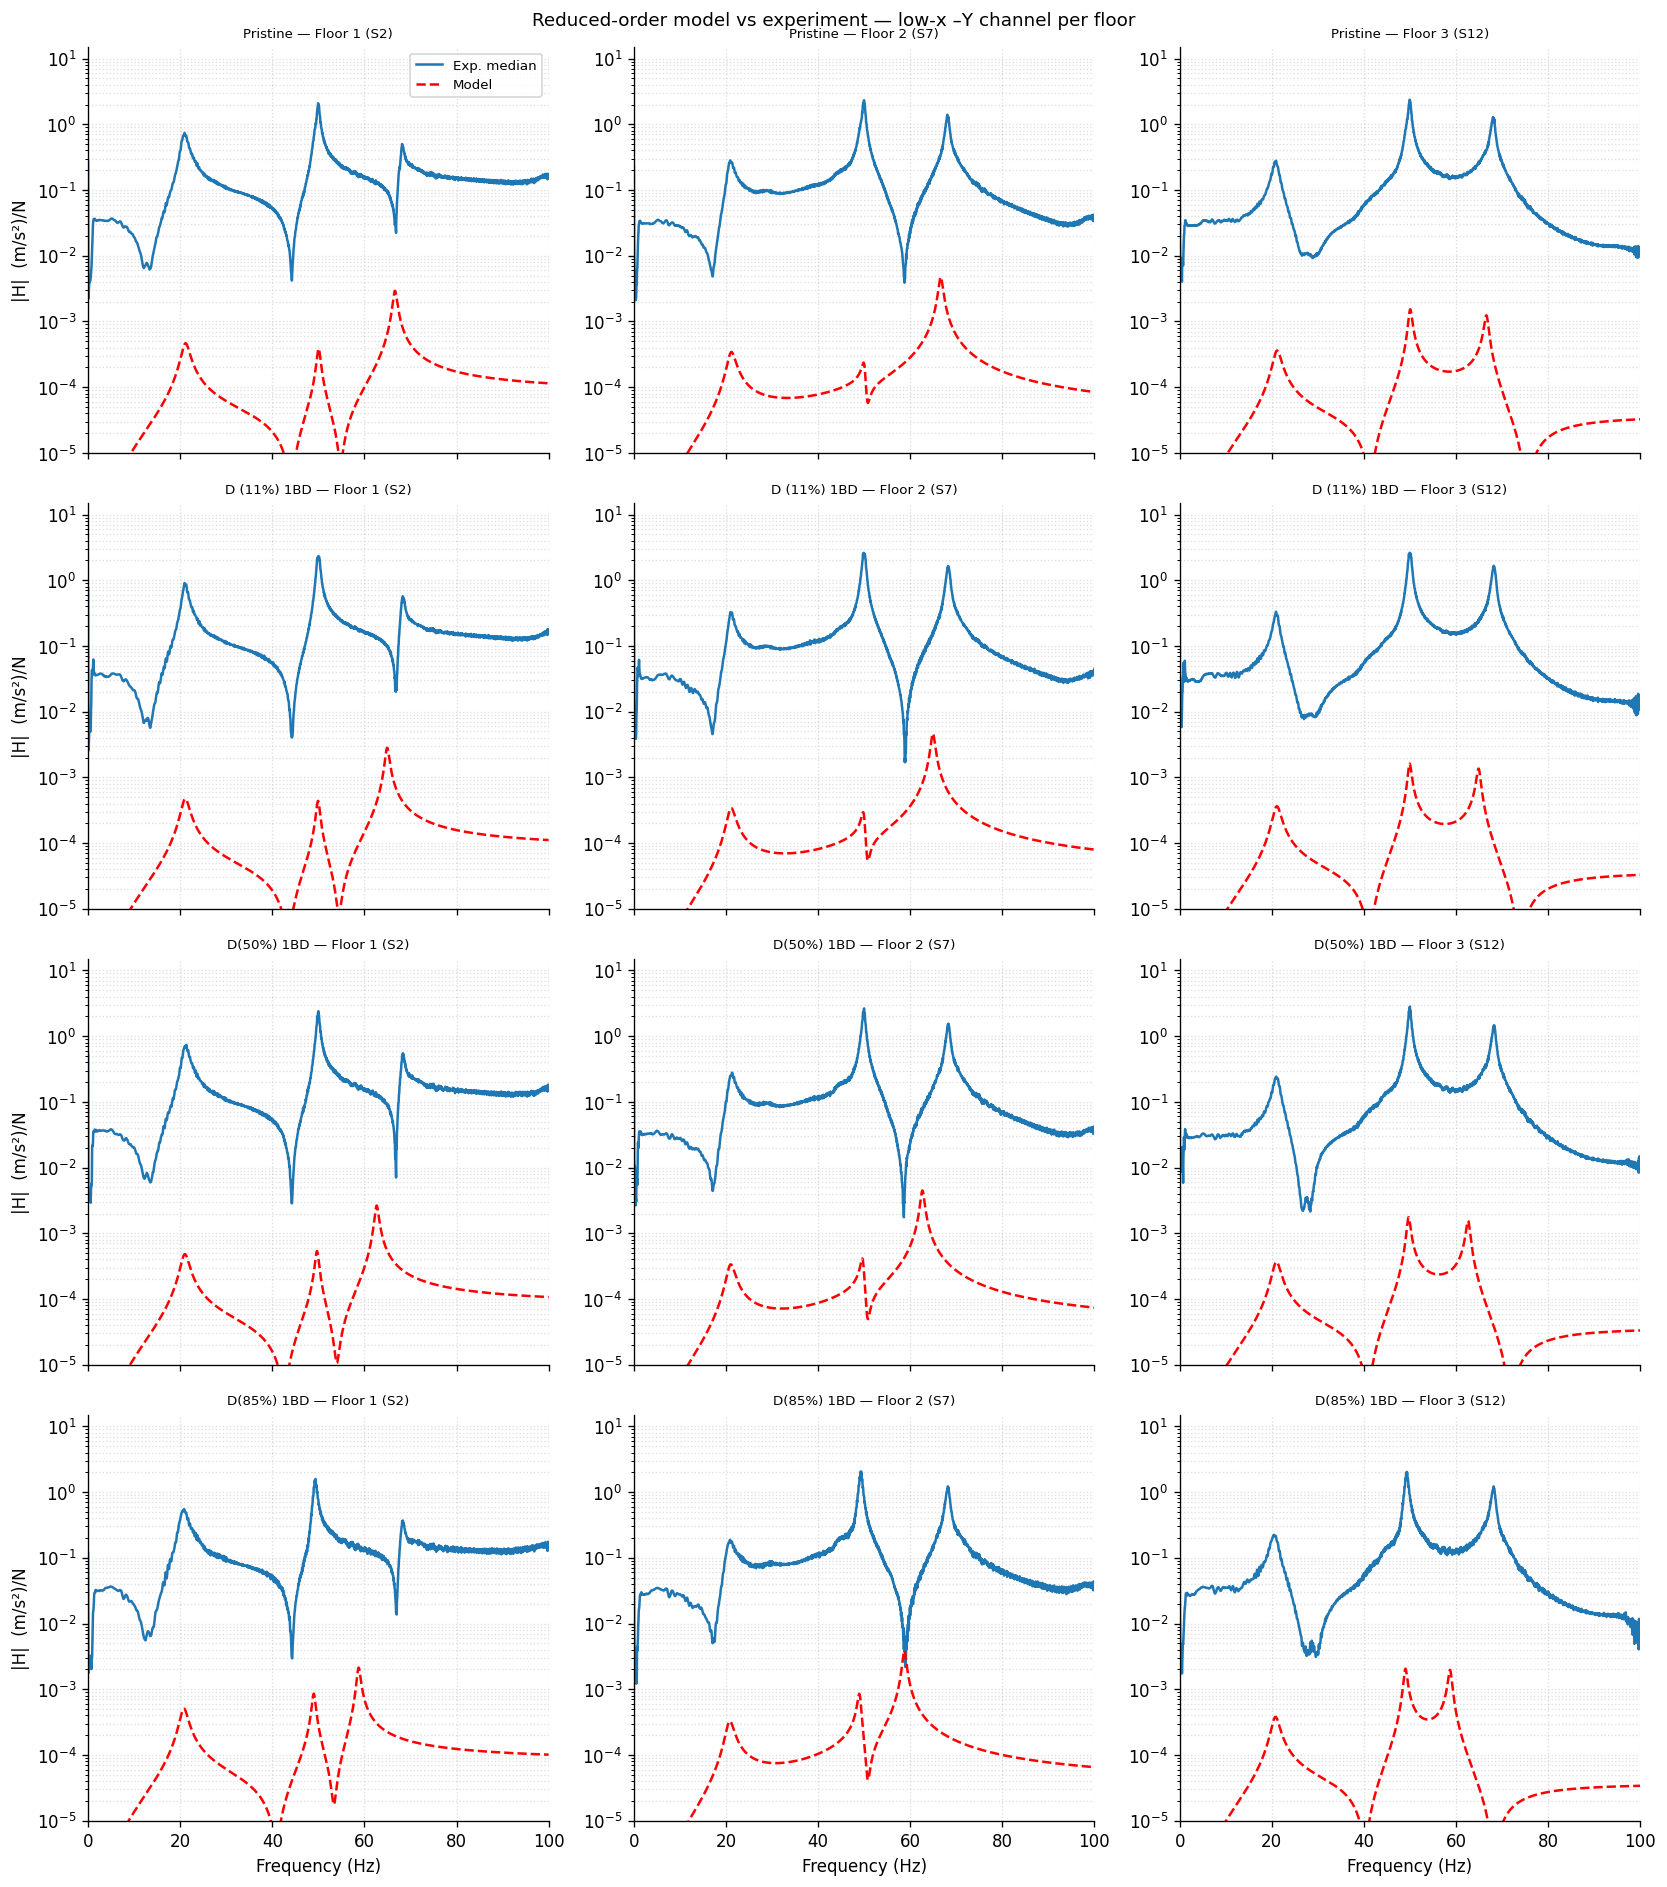

In [8]:
def syn_idx(label):
    for i, nm in enumerate(syn_cnames):
        if nm == label:
            return i
    return None

compare_pairs = [
    ('Pristine',    'Pristine',          'Pristine'),
    ('D(11%) 1BD',  'D (11%) 1BD',       'D (11%) 1BD'),
    ('D(50%) 1BD',  'D(50%) 1BD',        'D(50%) 1BD'),
    ('D(85%) 1BD',  'Damage (85%) 1BD',  'D(85%) 1BD'),
]

fig, axes = plt.subplots(len(compare_pairs), 3,
                          figsize=(14, 4 * len(compare_pairs)), sharex=True)
for row, (syn_lbl, exp_lbl, title) in enumerate(compare_pairs):
    si    = syn_idx(syn_lbl)
    H_exp = get_exp_case(exp_lbl)
    for fi, chans in enumerate(FLOOR_SIG):
        ax = axes[row, fi]
        ch = chans[0]
        if H_exp is not None and len(H_exp):
            med_exp = np.median(np.abs(H_exp[:, :, ch]), axis=0)
            ax.semilogy(exp_freq, med_exp, 'tab:blue', lw=1.5, label='Exp. median')
        if si is not None:
            ax.semilogy(syn_freqs, np.abs(syn_data[si, :, ch]),
                        'r--', lw=1.5, label='Model')
        ax.set_title(f'{title} — Floor {fi+1} ({SIG_LABELS[chans[0]]})', fontsize=8)
        ax.set_ylim(1e-5, 15); ax.set_xlim(0, 100)
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if row == len(compare_pairs) - 1:
            ax.set_xlabel('Frequency (Hz)')
        if fi == 0:
            ax.set_ylabel('|H|  (m/s²)/N')
        if row == 0 and fi == 0:
            ax.legend(fontsize=8)

fig.suptitle('Reduced-order model vs experiment — low-x –Y channel per floor', fontsize=11)
plt.tight_layout()
plt.show()

## 6b. All-sensor model vs experiment

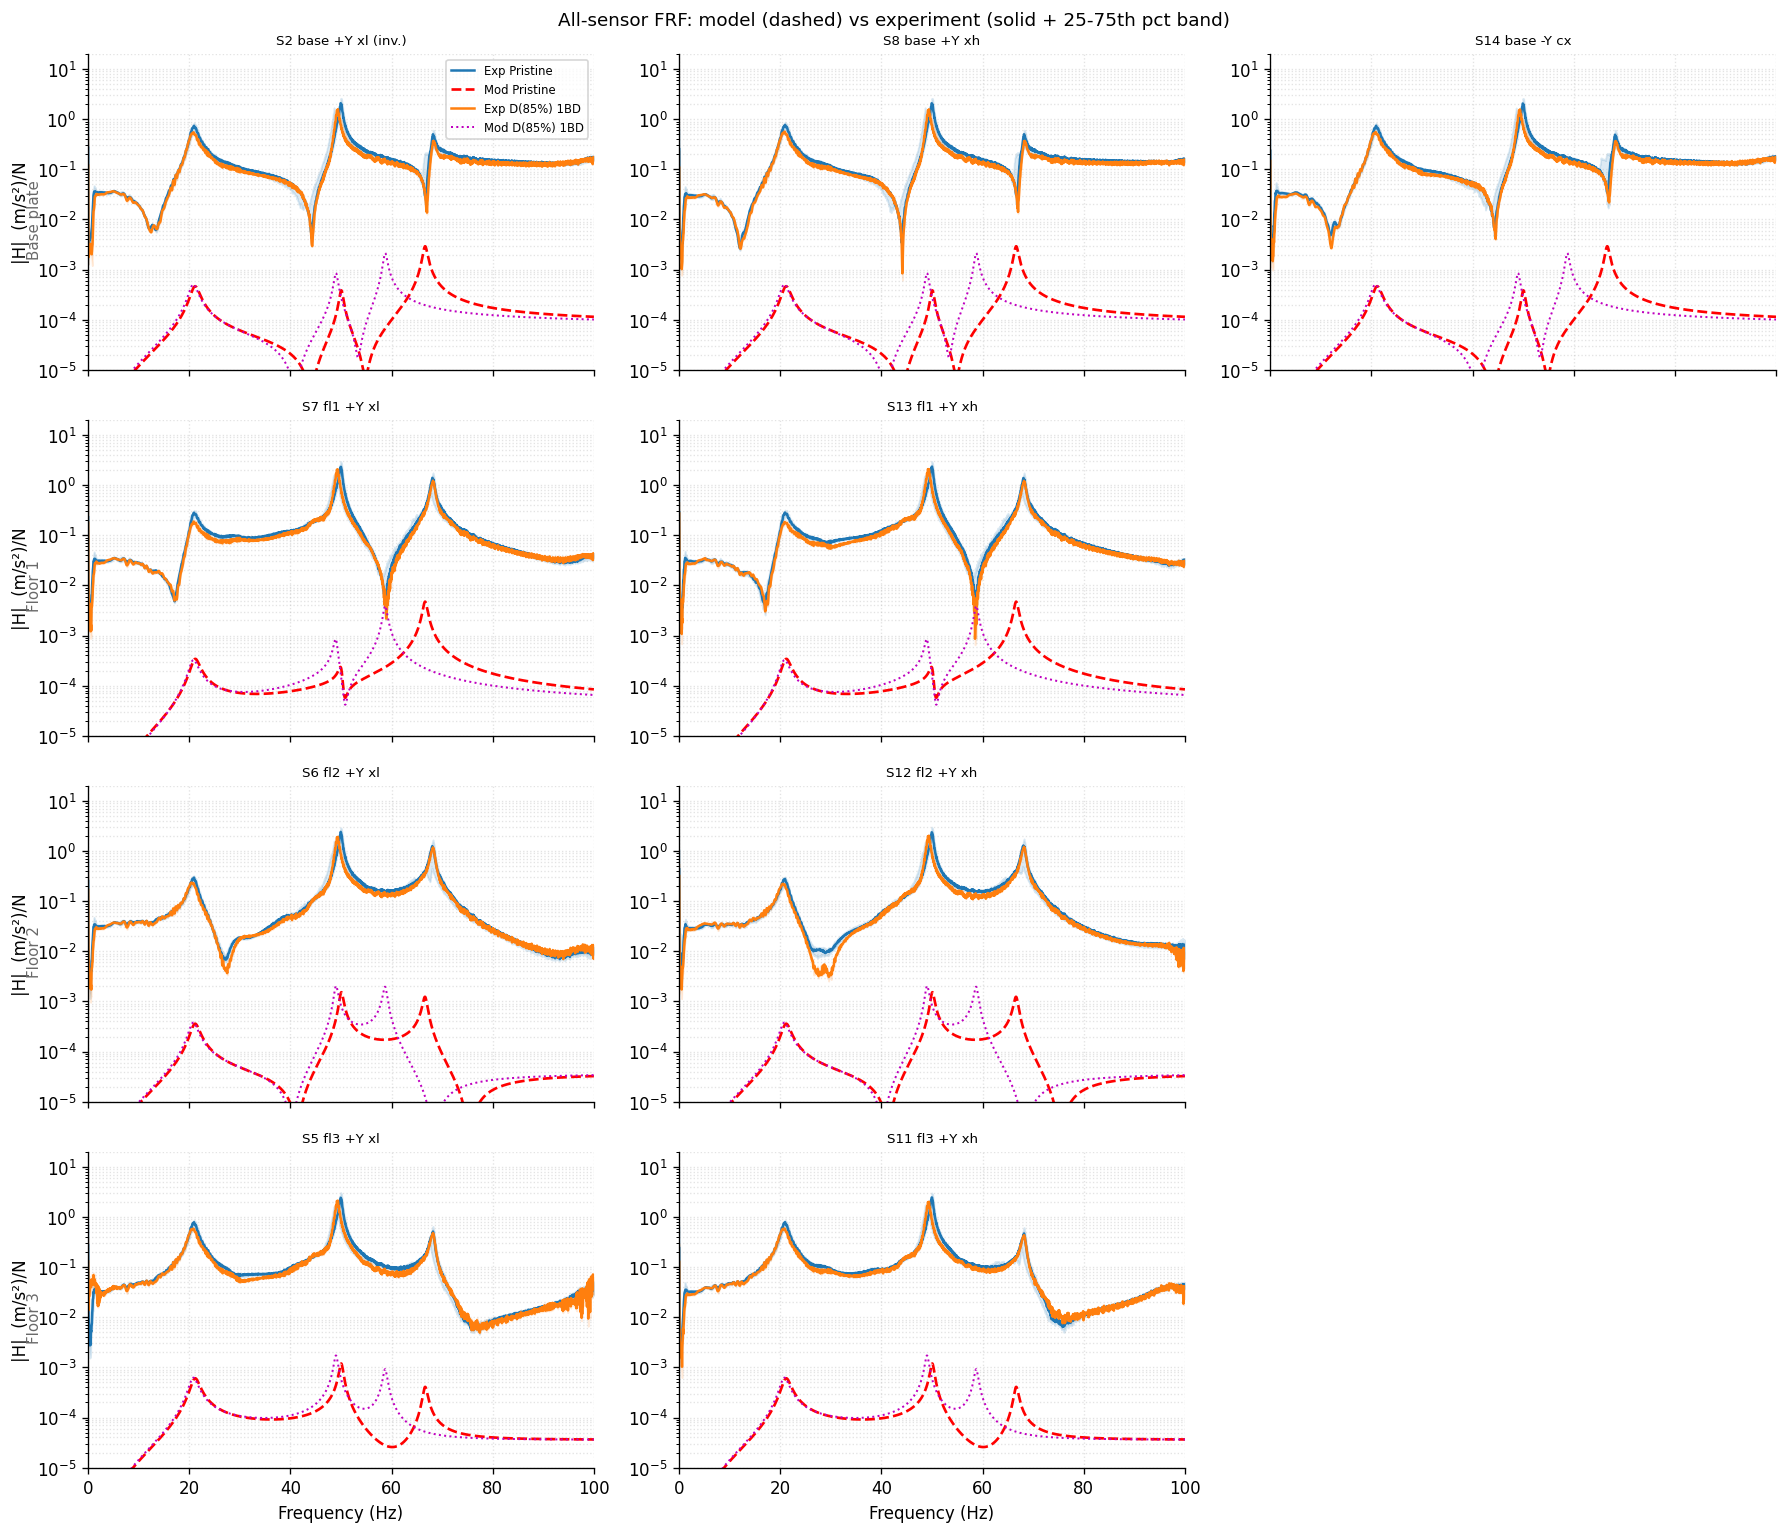

In [9]:
# ── All-sensor model vs experiment comparison ─────────────────────────────────
# Rows: base sensors, floor 1, floor 2, floor 3
# Cols: low-x  (+Y), high-x (+Y), [base: -Y cx]
GRID_CH = [
    [0, 4, 8],   # base plate: S2(xl), S8(xh), S14(cx -Y)
    [3, 7, -1],  # floor 1:    S7(xl), S13(xh)
    [2, 6, -1],  # floor 2:    S6(xl), S12(xh)
    [1, 5, -1],  # floor 3:    S5(xl), S11(xh)
]
CH_NAMES = [
    "S2 base +Y xl (inv.)", "S5 fl3 +Y xl", "S6 fl2 +Y xl",
    "S7 fl1 +Y xl",         "S8 base +Y xh","S11 fl3 +Y xh",
    "S12 fl2 +Y xh",        "S13 fl1 +Y xh","S14 base -Y cx"
]
ROW_LABELS = ["Base plate", "Floor 1", "Floor 2", "Floor 3"]
COL_LABELS = ["Low-X  (xl=0.013 m)", "High-X  (xh=0.292 m)", "Centre  (cx=0.152 m)"]

# Cases: synthetic label -> experimental case label
COMPARE_CASES = [
    ("Pristine",   "Pristine",        "tab:blue",   "r--",  1.6),
    ("D(85%) 1BD", "Damage (85%) 1BD","tab:orange",  "m:",  1.2),
]

fig, axes = plt.subplots(4, 3, figsize=(15, 13), sharex=True)
fig.suptitle("All-sensor FRF: model (dashed) vs experiment (solid + 25-75th pct band)",
             fontsize=11)

for ri, row_chs in enumerate(GRID_CH):
    for ci, chi in enumerate(row_chs):
        ax = axes[ri, ci]
        if chi < 0:
            ax.set_visible(False)
            continue
        ax.set_title(CH_NAMES[chi], fontsize=8)
        ax.set_xlim(0, 100); ax.set_ylim(1e-5, 20)
        ax.grid(True, which="both", ls=":", alpha=0.35)
        if ri == 3: ax.set_xlabel("Frequency (Hz)")
        if ci == 0: ax.set_ylabel("|H|  (m/s\xb2)/N")

        for (syn_lbl, exp_lbl, ec, mfmt, mlw) in COMPARE_CASES:
            # Experimental
            H_med  = get_exp_case(exp_lbl)
            if H_med is not None and len(H_med):
                med = np.median(np.abs(H_med[:,:,chi]), axis=0)
                lo  = np.percentile(np.abs(H_med[:,:,chi]), 25, axis=0)
                hi  = np.percentile(np.abs(H_med[:,:,chi]), 75, axis=0)
                ax.semilogy(exp_freq, med, color=ec, lw=1.5, label=f"Exp {syn_lbl}")
                ax.fill_between(exp_freq, lo, hi, color=ec, alpha=0.15)
            # Model
            si = syn_idx(syn_lbl)
            if si is not None:
                ax.semilogy(syn_freqs, np.abs(syn_data[si, :, chi]),
                            mfmt, lw=mlw, label=f"Mod {syn_lbl}")

# Row / col annotations
for ri in range(4):
    axes[ri, 0].text(-12, 1e-2, ROW_LABELS[ri], rotation=90,
                     va="center", fontsize=9, color="dimgray",
                     transform=axes[ri,0].transData)
axes[0, 0].legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()


## 7. CFDAC matrices (damage indicator)

The **Complex Frequency Domain Assurance Criterion (CFDAC)** is computed as:

$$\text{CFDAC}_{ij} = \frac{|\mathbf{H}_i \mathbf{H}_j^H|^2}
{(\mathbf{H}_i \mathbf{H}_i^H)(\mathbf{H}_j \mathbf{H}_j^H)}$$

where rows are L2-normalised over frequency. Values near 1 → high correlation
(similar structural state); deviations detect changes.

/sessions/gifted-ecstatic-hopper/tmp/ipykernel_5/4073052518.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


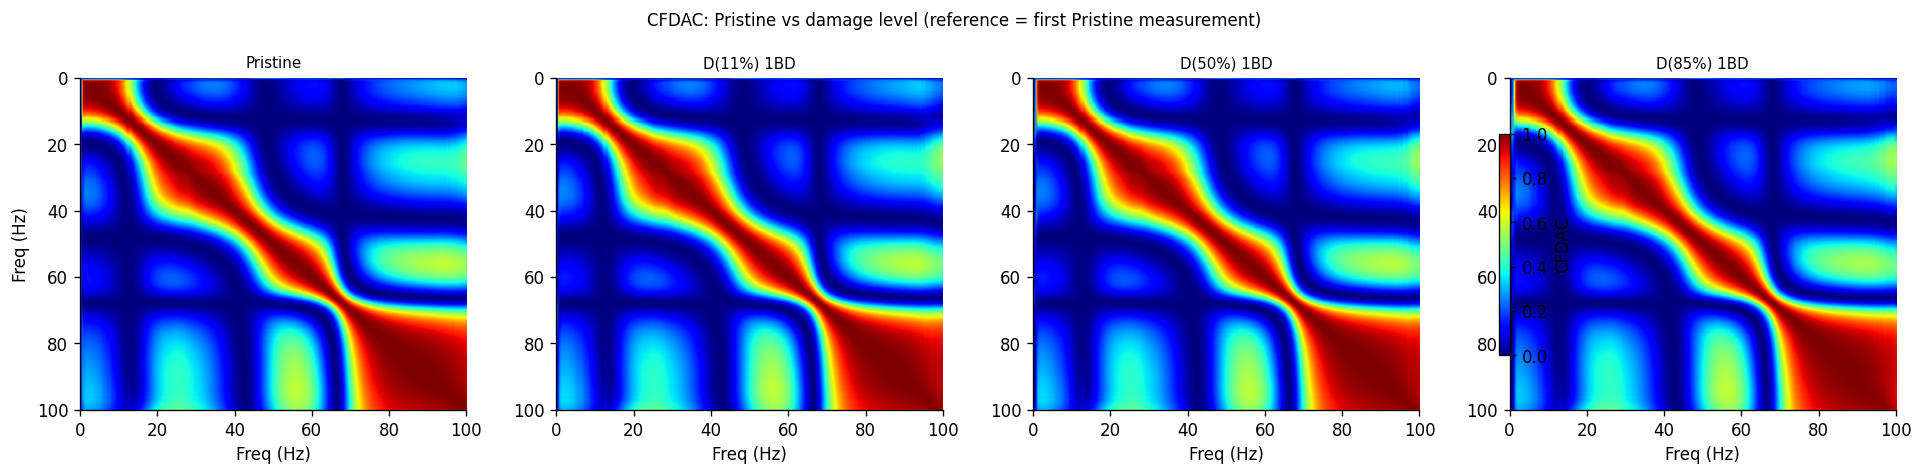

In [10]:
def first_sample(case_name):
    idx = exp_lmap.get(case_name)
    if idx is None:
        return None
    mask = exp_labels == idx
    return exp_data[mask][0] if mask.any() else None

def cfdac(H1, H2):
    R1 = H1 / (np.linalg.norm(H1, axis=1, keepdims=True) + 1e-30)
    R2 = H2 / (np.linalg.norm(H2, axis=1, keepdims=True) + 1e-30)
    return np.abs(R1 @ R2.conj().T) ** 2

show_cases = [
    ('Pristine',    'Pristine'),
    ('D(11%) 1BD',  'D (11%) 1BD'),
    ('D(50%) 1BD',  'D(50%) 1BD'),
    ('D(85%) 1BD',  'Damage (85%) 1BD'),
]

Href = first_sample('Pristine')
assert Href is not None

n_show = len(show_cases)
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
last_im = None
for col, (disp_name, exp_case) in enumerate(show_cases):
    ax = axes[col]
    H  = first_sample(exp_case)
    if H is None:
        ax.set_title(f'{disp_name}\n(no data)', fontsize=9)
        ax.axis('off')
        continue
    C = cfdac(Href, H)
    last_im = ax.imshow(C, vmin=0, vmax=1, aspect='auto',
                        extent=[0,100,100,0], cmap='jet')
    ax.set_title(disp_name, fontsize=9)
    ax.set_xlabel('Freq (Hz)')
    if col == 0:
        ax.set_ylabel('Freq (Hz)')

if last_im is not None:
    fig.colorbar(last_im, ax=axes.ravel().tolist(), label='CFDAC', shrink=0.6)

fig.suptitle('CFDAC: Pristine vs damage level (reference = first Pristine measurement)',
             fontsize=10)
plt.tight_layout()
plt.show()

## 8. Experimental variability analysis

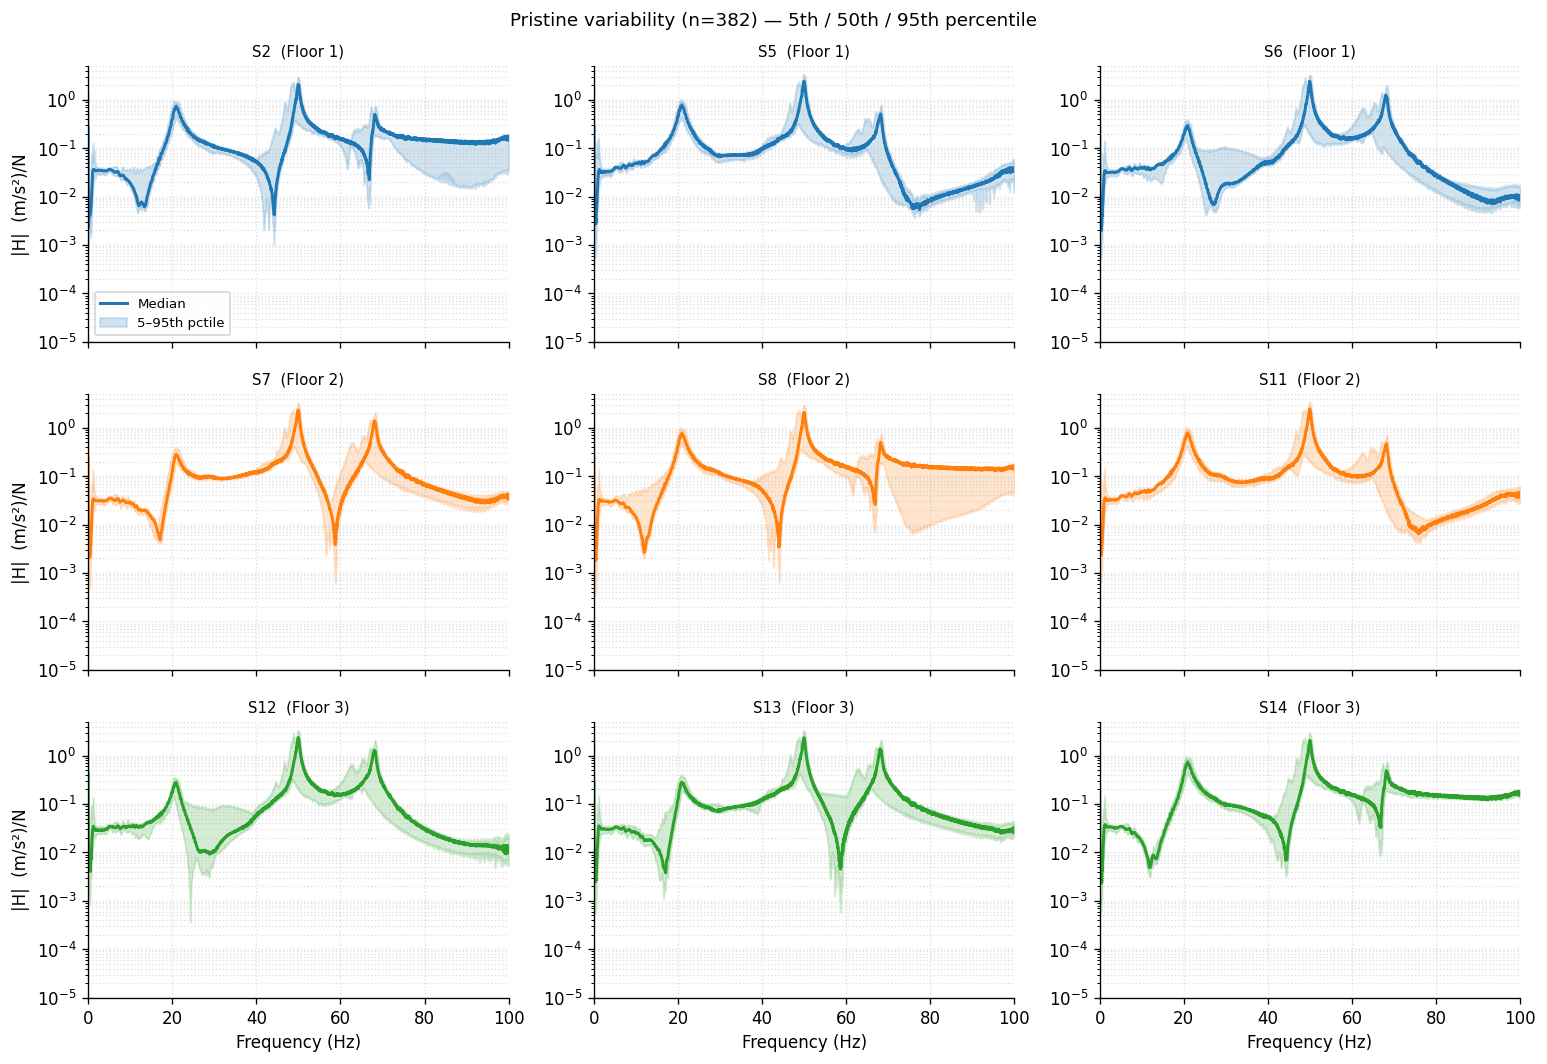

In [11]:
pristine_H = get_exp_case('Pristine')

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
for fi, chans in enumerate(FLOOR_SIG):
    for ci, ch in enumerate(chans):
        ax  = axes[fi][ci]
        col = FLOOR_COLS[fi]
        mag = np.abs(pristine_H[:, :, ch])
        p5  = np.percentile(mag,  5, axis=0)
        p50 = np.percentile(mag, 50, axis=0)
        p95 = np.percentile(mag, 95, axis=0)
        ax.semilogy(exp_freq, p50, color=col, lw=1.8, label='Median')
        ax.fill_between(exp_freq, p5, p95, color=col, alpha=0.2, label='5–95th pctile')
        ax.set_title(f'{SIG_LABELS[ch]}  (Floor {fi+1})', fontsize=9)
        ax.set_ylim(1e-5, 5); ax.set_xlim(0, 100)
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if fi == 2: ax.set_xlabel('Frequency (Hz)')
        if ci == 0: ax.set_ylabel('|H|  (m/s²)/N')
        if fi == 0 and ci == 0: ax.legend(fontsize=8)

fig.suptitle(f'Pristine variability (n={len(pristine_H)}) — 5th / 50th / 95th percentile',
             fontsize=11)
plt.tight_layout()
plt.show()